<a href="https://colab.research.google.com/github/angiemarian123456-art/METODOS-NUMERICOS-1/blob/main/PUNTO_FIJO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<>:56: SyntaxWarning: invalid escape sequence '\s'
<>:56: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1316/2904755674.py:56: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(x_vals, y_g, label='$g(x) = \sqrt{\\frac{10}{4+x}}$', color='blue', linewidth=1.5)


Iter (n)  p_0            p_n            Error (|p_n - p_0|)
-------------------------------------------------------
1         1.5000000       1.3483997       0.1516003
2         1.3483997       1.3673764       0.0189766
3         1.3673764       1.3649570       0.0024194
4         1.3649570       1.3652647       0.0003077
5         1.3652647       1.3652256       0.0000392

Raíz aproximada encontrada: p = 1.3652256
Total de iteraciones realizadas: 5



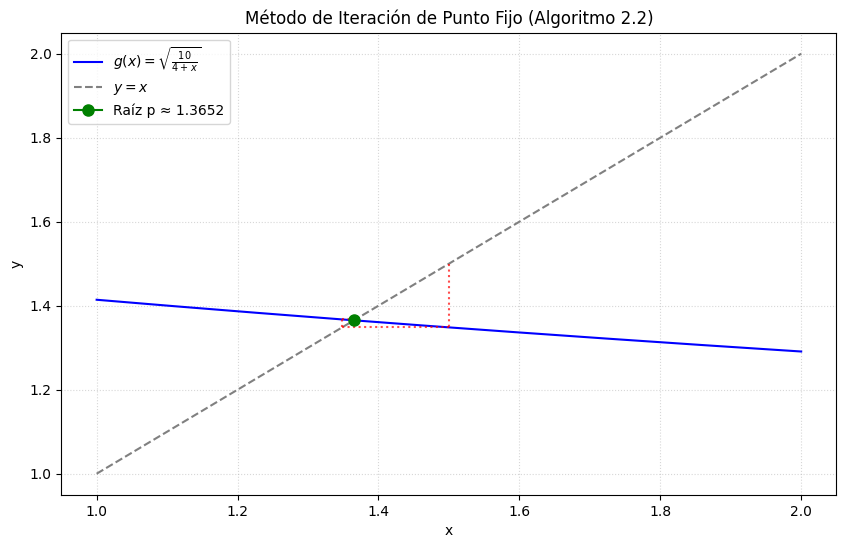

In [1]:
import numpy as np
import matplotlib.pyplot as plt
#### 1. IMPLEMENTACIÓN DEL ALGORITMO 2.2 ITERACIÓN DE PUNTO FIJO ####
def punto_fijo(g, p0, tol, max_iter):
    i = 1
    historial = []

    # Ciclo del algoritmo
    while i <= max_iter:
        p = g(p0)
        error = abs(p - p0)

        # Guardamos los datos para mostrarlos en la tabla
        historial.append([i, p0, p, error])

        # Criterio (si el error es menor a la tolerancia)
        if error < tol:
            return p, historial

        i += 1
        p0 = p  # Actualizamos p0 para la siguiente iteración

    print("El método falló después de alcanzar el máximo de iteraciones.")
    return p, historial
#### 2. DEFINICIÓN DE LA FUNCIÓN/EJEMPLO DEL LIBRO ####
# Usamos la opción (d) del libro: g(x) = raíz_cuadrada(10 / (4 + x))
def g(x):
    return np.sqrt(10 / (4 + x))

# Parámetros
p0_inicial = 1.5
tolerancia = 1e-4
max_iteraciones = 30

# Ejecutamos
raiz, tabla = punto_fijo(g, p0_inicial, tolerancia, max_iteraciones)

# Imprimimos
print(f"{'Iter (n)':<10}{'p_0':<15}{'p_n':<15}{'Error (|p_n - p_0|)':<15}")
print("-" * 55)
for fila in tabla:
    print(f"{fila[0]:<10}{fila[1]:.7f}       {fila[2]:.7f}       {fila[3]:.7f}")

print("\n" + "="*45)
print(f"Raíz aproximada encontrada: p = {raiz:.7f}")
print(f"Total de iteraciones realizadas: {len(tabla)}")
print("="*45 + "\n")

#### 3. GRAFICA ####
# Generamos puntos para graficar y = g(x) e y = x
x_vals = np.linspace(1.0, 2.0, 200)
y_g = g(x_vals)
y_identidad = x_vals  # Línea y = x

plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_g, label='$g(x) = \sqrt{\\frac{10}{4+x}}$', color='blue', linewidth=1.5)
plt.plot(x_vals, y_identidad, label='$y = x$', color='gray', linestyle='--')

# Dibujamos las líneas de iteración (recorrido de punto fijo)
p_actual = p0_inicial
for fila in tabla[:5]:  # Graficamos las primeras 5 iteraciones
    p_siguiente = fila[2]
    # Línea vertical desde el eje o punto previo hacia la curva g(x)
    plt.plot([p_actual, p_actual], [p_actual, p_siguiente], color='red', linestyle=':', alpha=0.7)
    # Línea horizontal desde la curva g(x) hacia la recta y = x
    plt.plot([p_actual, p_siguiente], [p_siguiente, p_siguiente], color='red', linestyle=':', alpha=0.7)
    p_actual = p_siguiente

# Marcamos el punto de la raíz final
if raiz:
    plt.plot(raiz, g(raiz), marker='o', color='green', markersize=8, label=f'Raíz p ≈ {raiz:.4f}')

# Detalles de la gráfica
plt.title('Método de Iteración de Punto Fijo (Algoritmo 2.2)')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend()
plt.show()
